In this notebook we perform different tests in order to make feature selection on the merged dataset

In [2]:
!pip install feature_engine
import pandas as pd
import matplotlib.pyplot as plt
from merge_and_agregation import *
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

from sklearn.model_selection import train_test_split

from feature_engine.selection import (
    DropCorrelatedFeatures,
    SmartCorrelatedSelection,
    SelectByShuffling,
    SelectBySingleFeaturePerformance,
    RecursiveFeatureElimination,
)

In [3]:
#Load, agregate, clean and merge the files
df_portefeuille=pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";")
df_reclamations= pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_reclamations_2023_11.csv", sep=";")
df_interactions=pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_interactions_2023_11.csv", sep=";")
df_impayes= pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_impayes_2023_11.csv", sep=";")
df_consommations= pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_consommations_2023_11.csv", sep=";")

df_merged=create_clean_aggregated_dataset(df_consommations=df_consommations, df_impayes=df_impayes, df_reclamations=df_reclamations, df_portefeuille=df_portefeuille, df_interactions=df_interactions)

/tmp/ipykernel_13342/799911698.py:2: DtypeWarning: Columns (31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df_portefeuille=pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";")
/home/onyxia/work/bdc-alptis-g2/merge_and_agregation.py:511: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_portefeuille_cleaned["client_departement"].replace("00", pd.NA, inplace=True)
/home/onyxia/work/bdc-alptis-g2/merge_and_agregation.py:253: FutureWarning: DataFrame

### Features selection

In [4]:
#Let's first quickly visualise the correlated features in the merged dataset
#Criterion: the pearson coefficient
correlated = DropCorrelatedFeatures(variables=None, method='pearson', threshold=0.8)
correlated.fit(df_merged)
correlated.correlated_feature_dict_

{'client_anciennete_contrat_annees': {'client_code'},
 'client_code_postal': {'client_departement'},
 'client_cotisations_annualisees_n': {'client_cotisations_annualisees_n_moins1',
  'client_cotisations_annualisees_n_moins2',
  'client_cotisations_annualisees_n_plus1'},
 'client_nb_assures_contrat': {'client_nb_enfants'},
 'courtier_nb_affaires_n_moins1': {'courtier_nb_affaires_n_moins2',
  'courtier_nb_radiations_n_moins1',
  'courtier_nb_radiations_n_moins2'},
 'frais_reels': {'frais_reels_soins_medicaux',
  'reste_a_charge',
  'reste_a_charge_soins_medicaux'},
 'frais_reels_dentaire': {'nb_protheses_dentaires',
  'remb_alptis_dentaire',
  'remb_ro_dentaire'},
 'frais_reels_divers': {'remb_alptis_divers', 'remb_ro_divers'},
 'frais_reels_hospitalisation': {'remb_alptis_hospitalisation',
  'remb_ro',
  'remb_ro_hospitalisation'},
 'frais_reels_optique': {'nb_decomptes_optique',
  'remb_alptis_optique',
  'reste_a_charge_optique'},
 'frais_reels_pharmacie': {'remb_alptis_pharmacie', '

This analysis validates some of our previous hypothesis, including that the number of members in the contract directly depends on the familial situation. 


In [5]:
#Let's select the best features in each group of correlated features using RandomForest
#To identify the group of correlated features we use the Pearson coefficient again

X= df_merged.drop(columns="target_resiliation_6mois")
y= df_merged["target_resiliation_6mois"]

In [6]:
pd.set_option('display.max_columns', None)
X.head()

,client_code,client_age_souscripteur,client_code_postal,client_departement,client_a_conjoint,client_nb_enfants,client_nb_assures_contrat,client_a_garantie_prevoyance,client_produit,client_garantie_base,client_garantie_base_plus_options,client_millesime_tarifaire_produit,client_zone_tarifaire,client_type_zone_tarifaire,client_est_contrat_madelin,client_date_debut_effet_garantie,client_anciennete_contrat_annees,client_cotisations_annualisees_n_moins2,client_cotisations_annualisees_n_moins1,client_cotisations_annualisees_n,client_cotisations_annualisees_n_plus1,client_mode_paiement,client_frequence_paiement,client_nom_banque,client_nps_date_reponse_n,client_nps_note_reco_n,client_nps_verbatim_n,client_nps_date_reponse_n_moins1,client_nps_note_reco_n_moins1,client_nps_verbatim_n_moins1,courtier_code_partenaire,courtier_anciennete_annees,courtier_code_apporteur,courtier_est_escompte,courtier_nb_affaires_n_moins1,courtier_nb_radiations_n_moins1,courtier_nb_affaires_n_moins2,courtier_nb_radiations_n_moins2,client_male_souscripteur,client_demenagement_dans_les_12_mois,courtier_changement_dans_les_12_mois,client_structure_familiale_couple avec 1 enfant,client_structure_familiale_couple avec 2 enfants,client_structure_familiale_couple avec 3 enfants,client_structure_familiale_couple avec 4 enfants,client_structure_familiale_couple avec 5 enfants,client_structure_familiale_couple avec plus de 5 enfants,client_structure_familiale_couple ss enfant,client_structure_familiale_femme avec 1 enfant,client_structure_familiale_femme avec 2 enfants,client_structure_familiale_femme avec 3 enfants,client_structure_familiale_femme avec 4 enfants,client_structure_familiale_femme avec 5 enfants,client_structure_familiale_femme avec plus de 5 enfants,client_structure_familiale_femme ss enfant,client_structure_familiale_homme avec 1 enfant,client_structure_familiale_homme avec 2 enfants,client_structure_familiale_homme avec 3 enfants,client_structure_familiale_homme avec 4 enfants,client_structure_familiale_homme avec 5 enfants,client_structure_familiale_homme avec plus de 5 enfants,client_structure_familiale_homme ss enfant,courtier_segmentation_interne_Alptis,courtier_segmentation_interne_CMA,courtier_segmentation_interne_Dilemme,courtier_segmentation_interne_Filiale,courtier_segmentation_interne_Groupements,courtier_segmentation_interne_Inactif à relancer,courtier_segmentation_interne_Miltis,courtier_segmentation_interne_Non catégorisé,courtier_segmentation_interne_Nouveau,courtier_segmentation_interne_Opportuniste,courtier_segmentation_interne_Partenariats,courtier_segmentation_interne_Petit Producteur,courtier_segmentation_interne_Potentiel,courtier_segmentation_interne_Potentiel Agent,courtier_segmentation_interne_Sommeil,courtier_segmentation_interne_VADISTE,courtier_segmentation_interne_VIP,courtier_type_commission_lineaire,courtier_type_commission_lineaire_majore,courtier_type_commission_precompte,courtier_type_commission_precompte_majore,client_ro_souscripteur_A,client_ro_souscripteur_AM,client_ro_souscripteur_AMEXA,client_ro_souscripteur_ASSIM_SS,client_ro_souscripteur_CFE,client_ro_souscripteur_DDOM,client_ro_souscripteur_EDOM,client_ro_souscripteur_F,client_ro_souscripteur_MGEN,client_ro_souscripteur_MONACO,client_ro_souscripteur_NOTAIRE,client_ro_souscripteur_PRAGA,client_ro_souscripteur_PT,client_ro_souscripteur_RAM,client_ro_souscripteur_SA,client_ro_souscripteur_SNCF,client_ro_souscripteur_SS,client_ro_souscripteur_SSM,client_ro_souscripteur_TNS,courtier_reseau_courtage_AFFAIRE DIRECTE,courtier_reseau_courtage_COURTIER CLASSIQUE,courtier_reseau_courtage_COURTIER ESCOMPTE,courtier_reseau_courtage_E_COURTIER,recla_nombre,recla_motif_Couverture et fonctionnement de la garantie,recla_motif_Délai de traitement,recla_motif_Montant des remboursements / Indemnités,recla_motif_Frais,recla_motif_Demandes de compléments / pièces,recla_motif_Autre,recla_canal_entrant_principale,recla_canal_entrant_secondaire,recla_sensible_resiliation,recla_sensible

In [ ]:
smart_corr = SmartCorrelatedSelection( 
    method="pearson", 
    threshold=0.7, 
    missing_values="ignore",
    selection_method="model_performance", 
    estimator=RandomForestClassifier(n_estimators=10, random_state=1), # the model from which to derive the importance
)

smart_corr.fit(X, y)

In [6]:
#We can see which columns this methods suggest to drop
print(f"Columns to drop : {len(smart_corr.features_to_drop_)}")
smart_corr.features_to_drop_

Columns to drop : 38


['client_code',
 'client_code_postal',
 'client_cotisations_annualisees_n',
 'client_cotisations_annualisees_n_moins1',
 'client_cotisations_annualisees_n_moins2',
 'client_nb_enfants',
 'courtier_anciennete_annees',
 'courtier_code_apporteur',
 'courtier_nb_affaires_n_moins2',
 'courtier_nb_radiations_n_moins1',
 'courtier_nb_radiations_n_moins2',
 'frais_reels',
 'frais_reels_soins_medicaux',
 'reste_a_charge',
 'frais_reels_dentaire',
 'remb_alptis_dentaire',
 'remb_ro_dentaire',
 'reste_a_charge_dentaire',
 'frais_reels_divers',
 'remb_ro_divers',
 'frais_reels_hospitalisation',
 'remb_ro',
 'remb_ro_hospitalisation',
 'frais_reels_optique',
 'remb_alptis_optique',
 'reste_a_charge_optique',
 'remb_alptis_pharmacie',
 'remb_ro_pharmacie',
 'impaye_action_annonce_contentieux',
 'impaye_action_mise_en_demeure',
 'interaction_canal_telephone_nb',
 'interaction_nb_transferts_externalises',
 'interaction_motif_frais_courants',
 'nb_decomptes',
 'nb_decomptes_soins_medicaux',
 'recla_del

### Features importance

Let's deep more into the interaction between these important features and the target with a Shap Values test.

In [ ]:
columns_to_keep = list(set(df_merged.columns)- set(smart_corr.features_to_drop_ + ["target_resiliation_6mois"]))

In [30]:
X = X[columns_to_keep].select_dtypes(exclude="object")

In [8]:
X.shape

(132576, 136)

In [9]:
print(list(X.columns))

['recla_sensible_autre', 'courtier_segmentation_interne_Miltis', 'client_ro_souscripteur_TNS', 'client_structure_familiale_couple avec 5 enfants', 'client_structure_familiale_homme avec 3 enfants', 'client_ro_souscripteur_EDOM', 'impaye_nb_actions', 'interaction_service_suivi_du_contrat', 'courtier_segmentation_interne_Partenariats', 'courtier_changement_dans_les_12_mois', 'client_structure_familiale_femme avec 4 enfants', 'client_est_contrat_madelin', 'courtier_segmentation_interne_Potentiel', 'courtier_type_commission_precompte', 'nb_jours_chambre_particuliere', 'courtier_segmentation_interne_Dilemme', 'nb_decomptes_hospitalisation', 'courtier_type_commission_precompte_majore', 'courtier_segmentation_interne_Opportuniste', 'client_anciennete_contrat_annees', 'interaction_motif_optique', 'courtier_segmentation_interne_Potentiel Agent', 'client_age_souscripteur', 'client_nps_note_reco_n_moins1', 'client_ro_souscripteur_SNCF', 'frais_reels_pharmacie', 'client_ro_souscripteur_DDOM', 'int

In [10]:
X.isna().sum()[X.isna().sum() > 0].sort_values(ascending=False)

client_nps_note_reco_n_moins1     127060
client_nps_note_reco_n            125100
nb_jours_chambre_particuliere      11669
nb_protheses_dentaires             11669
reste_a_charge_pharmacie           11669
nb_jours_forfait_journalier        11669
reste_a_charge_divers              11669
reste_a_charge_hospitalisation     11669
reste_a_charge_soins_medicaux      11669
dtype: int64

In [11]:
X[X.isna().any(axis=1)]

,recla_sensible_autre,courtier_segmentation_interne_Miltis,client_ro_souscripteur_TNS,client_structure_familiale_couple avec 5 enfants,client_structure_familiale_homme avec 3 enfants,client_ro_souscripteur_EDOM,impaye_nb_actions,interaction_service_suivi_du_contrat,courtier_segmentation_interne_Partenariats,courtier_changement_dans_les_12_mois,...,courtier_segmentation_interne_CMA,remb_alptis_hospitalisation,reste_a_charge_soins_medicaux,client_structure_familiale_homme avec 1 enfant,client_structure_familiale_couple avec 4 enfants,client_ro_souscripteur_MONACO,courtier_reseau_courtage_AFFAIRE DIRECTE,courtier_reseau_courtage_COURTIER CLASSIQUE,impaye_action_2eme_impaye,client_structure_familiale_femme avec 5 enfants
0,0.0,False,False,False,False,False,0.0,0.0,False,0,...,False,0.00,0.00,False,False,False,True,False,0.0,False
1,0.0,False,False,False,False,False,0.0,0.0,False,1,...,False,0.00,0.00,False,False,False,True,False,0.0,False
2,0.0,False,True,False,False,False,0.0,0.0,False,0,...,False,294.00,127.00,False,False,False,True,False,0.0,False
3,0.0,False,True,False,False,False,0.0,0.0,False,1,...,False,0.00,95.50,False,False,False,True,False,0.0,False
4,0.0,False,True,False,False,False,0.0,0.0,False,0,...,False,1901.42,332.04,False,False,False,True,False,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132571,0.0,False,False,False,False,False,0.0,1.0,False,0,...,True,0.00,NaN,False,False,False,False,False,0.0,False
132572,0.0,False,False,False,False,False,0.0,0.0,False,0,...,False,0.00,NaN,False,False,False,False,True,0.0,False
132573,0.0,False,False,False,False,False,0.0,0.0,False,0,...,False,0.00,NaN,False,False,False,False,True,0.0,False
132574,0.0,True,False,False,False,False,0.0,0.0,False,0,...,False,0.00,NaN,False,False,False,False,True,0.0,False


In [12]:
X["nps_available"] = X["client_nps_note_reco_n"].notna().astype(int)
X["client_nps_note_reco_n"] = X["client_nps_note_reco_n"].fillna(-1)

X["nps_available_n_moins1"] = X["client_nps_note_reco_n_moins1"].notna().astype(int)
X["client_nps_note_reco_n_moins1"] = X["client_nps_note_reco_n_moins1"].fillna(-1)


In [13]:
cols_zero = [
    "reste_a_charge_hospitalisation",
    "nb_jours_chambre_particuliere",
    "reste_a_charge_divers",
    "nb_jours_forfait_journalier",
    "reste_a_charge_pharmacie",
    "reste_a_charge_soins_medicaux",
    "nb_protheses_dentaires"
]

X[cols_zero] = X[cols_zero].fillna(0)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, train_size=0.7)

### Variable Selection via Penalized Logistic Regression

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

lasso_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegressionCV(
        penalty="l1",
        solver="saga",
        class_weight="balanced",
        Cs=20,
        cv=5,
        scoring="f1",
        max_iter=5000,
        n_jobs=-1
    ))
])

lasso_pipe.fit(X_train, y_train)


/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",20
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist

In [16]:
y_pred= lasso_pipe.predict(X_test)

#Score on test data
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.67      0.95      0.79     25107
           1       0.70      0.20      0.32     14666

    accuracy                           0.67     39773
   macro avg       0.68      0.58      0.55     39773
weighted avg       0.68      0.67      0.61     39773



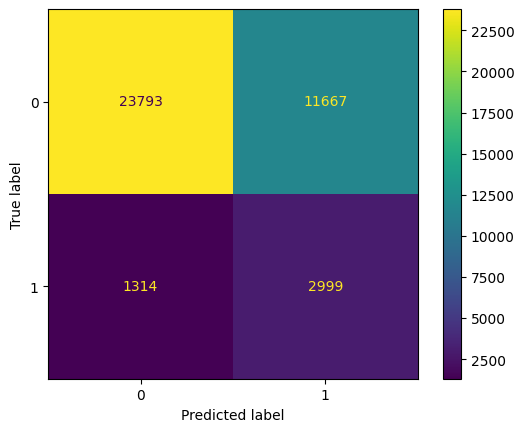

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

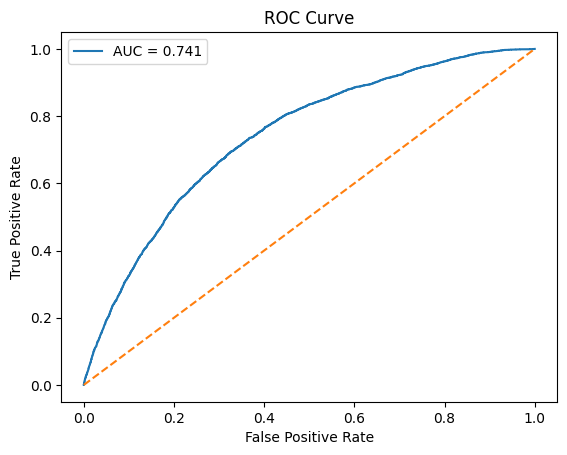

In [18]:
# Probabilités pour la classe 1 (churn)
y_proba = lasso_pipe.predict_proba(X_test)[:, 1]

# Calcul ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # ligne aléatoire
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [19]:
coef_lasso = pd.Series(
    lasso_pipe.named_steps["model"].coef_[0],
    index=X_train.columns
)

droped_coefs_lasso = coef_lasso[coef_lasso == 0].sort_values()
print(droped_coefs_lasso)

recla_sensible_autre                               0.0
client_ro_souscripteur_EDOM                        0.0
client_structure_familiale_femme avec 4 enfants    0.0
client_ro_souscripteur_DDOM                        0.0
interaction_motif_hospitalisation                  0.0
client_ro_souscripteur_F                           0.0
client_structure_familiale_femme avec 1 enfant     0.0
recla_motif_Demandes de compléments / pièces       0.0
impaye_action_1ere_lettre_relance                  0.0
interaction_service_prestations_sante              0.0
impaye_montant_total                               0.0
client_a_conjoint                                  0.0
courtier_segmentation_interne_CMA                  0.0
dtype: float64


In [20]:
ridge_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegressionCV(
        penalty="l2",
        solver="lbfgs",
        class_weight="balanced",
        Cs=20,
        cv=5,
        scoring="f1",
        max_iter=5000,
        n_jobs=-1
    ))
])

ridge_pipe.fit(X_train, y_train)


/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",20
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist

In [21]:
y_pred= ridge_pipe.predict(X_test)

#Score on test data
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.68      0.95      0.79     25304
           1       0.69      0.20      0.31     14469

    accuracy                           0.68     39773
   macro avg       0.68      0.58      0.55     39773
weighted avg       0.68      0.68      0.62     39773



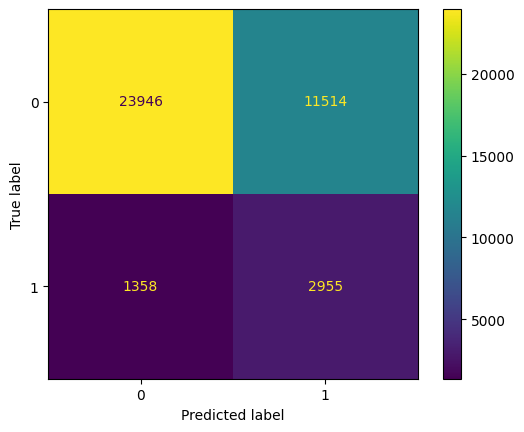

In [22]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

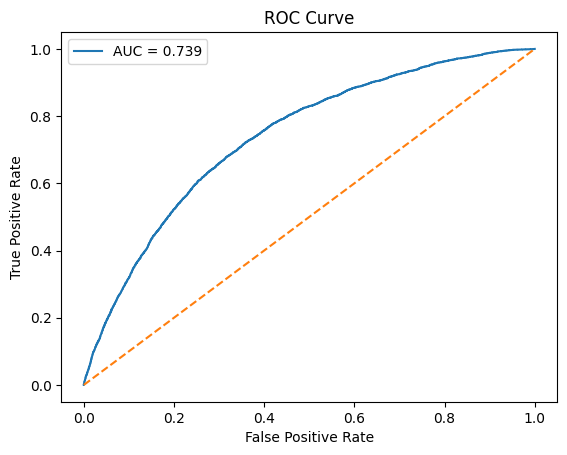

In [23]:
# Probabilités pour la classe 1 (churn)
y_proba = ridge_pipe.predict_proba(X_test)[:, 1]

# Calcul ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # ligne aléatoire
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [26]:
coef_ridge = pd.Series(
    ridge_pipe.named_steps["model"].coef_[0],
    index=X_train.columns
)

droped_coefs_ridge = coef_ridge[coef_ridge == 0].sort_values()
print(droped_coefs_ridge)

client_ro_souscripteur_EDOM    0.0
client_ro_souscripteur_F       0.0
dtype: float64


In [25]:
enet_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegressionCV(
        penalty="elasticnet",
        solver="saga",
        class_weight="balanced",
        l1_ratios=[0.2, 0.5, 0.8],
        Cs=20,
        cv=5,
        scoring="f1",
        max_iter=7000,
        n_jobs=-1
    ))
])

enet_pipe.fit(X_train, y_train)


/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
y_pred= enet_pipe.predict(X_test)

#Score on test data
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.67      0.95      0.79     25204
           1       0.69      0.20      0.32     14569

    accuracy                           0.68     39773
   macro avg       0.68      0.58      0.55     39773
weighted avg       0.68      0.68      0.61     39773



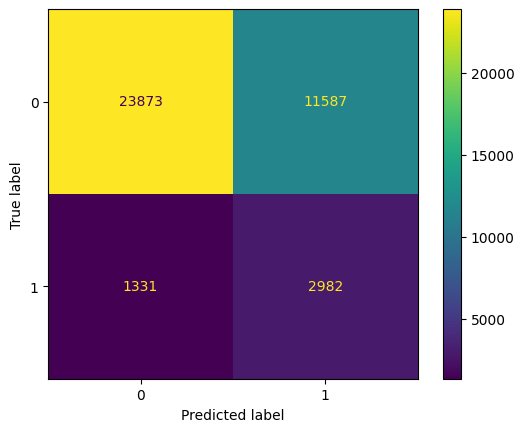

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

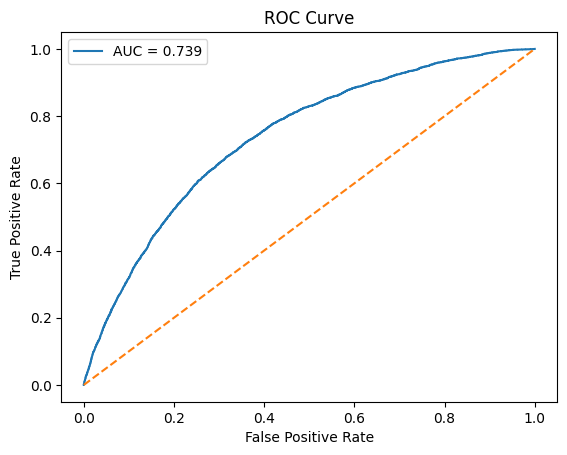

In [ ]:
# Probabilités pour la classe 1 (churn)
y_proba = ridge_pipe.predict_proba(X_test)[:, 1]

# Calcul ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # ligne aléatoire
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
coef_enet = pd.Series(
    enet_pipe.named_steps["model"].coef_[0],
    index=X_train.columns
)

droped_coefs_enet = coef_enet[coef_enet == 0].sort_values()
print(droped_coefs_enet)

impaye_montant_total                                       0.0
client_ro_souscripteur_EDOM                                0.0
client_ro_souscripteur_ASSIM_SS                            0.0
client_structure_familiale_couple avec 4 enfants           0.0
courtier_segmentation_interne_Partenariats                 0.0
client_structure_familiale_homme avec 4 enfants            0.0
client_ro_souscripteur_DDOM                                0.0
impaye_action_suspension_garanties                         0.0
client_ro_souscripteur_SSM                                 0.0
nb_protheses_dentaires                                     0.0
client_ro_souscripteur_PT                                  0.0
client_structure_familiale_femme avec 1 enfant             0.0
client_structure_familiale_homme avec plus de 5 enfants    0.0
courtier_reseau_courtage_E_COURTIER                        0.0
client_a_conjoint                                          0.0
courtier_reseau_courtage_COURTIER ESCOMPTE             

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline(steps=[
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=50,   # utile en churn
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If

In [34]:
y_pred= rf_pipe.predict(X_test)

#Score on test data
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.75      0.94      0.84     28303
           1       0.64      0.24      0.35     11470

    accuracy                           0.74     39773
   macro avg       0.70      0.59      0.59     39773
weighted avg       0.72      0.74      0.70     39773



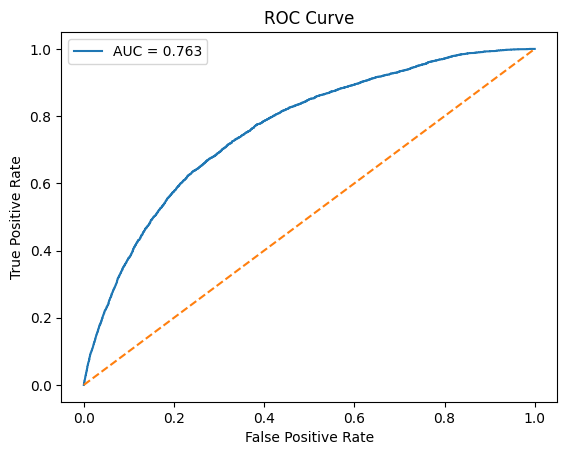

In [35]:
# Probabilités pour la classe 1 (churn)
y_proba = rf_pipe.predict_proba(X_test)[:, 1]

# Calcul ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # ligne aléatoire
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [36]:
droped_lasso = droped_coefs_lasso.index.tolist()
X_train = X_train.drop(columns=droped_lasso)
X_test  = X_test.drop(columns=droped_lasso)

In [37]:
rf_pipe.fit(X_train, y_train)

y_pred= rf_pipe.predict(X_test)

#Score on test data
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.76      0.94      0.84     28422
           1       0.63      0.24      0.35     11351

    accuracy                           0.74     39773
   macro avg       0.70      0.59      0.60     39773
weighted avg       0.72      0.74      0.70     39773



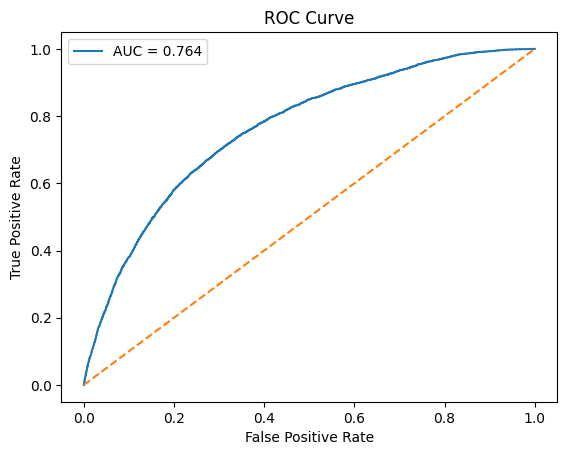

In [38]:
# Probabilités pour la classe 1 (churn)
y_proba = rf_pipe.predict_proba(X_test)[:, 1]

# Calcul ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # ligne aléatoire
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [39]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)


ValueError: Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
y_pred= gb.predict(X_test)

#Score on test data
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94     39512
           1       0.03      0.51      0.06       261

    accuracy                           0.89     39773
   macro avg       0.51      0.70      0.50     39773
weighted avg       0.99      0.89      0.94     39773



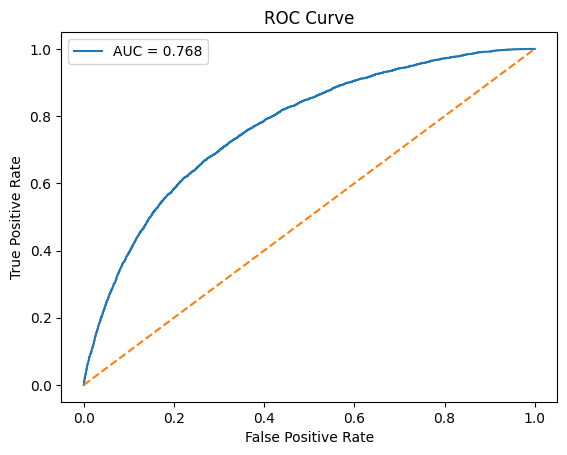

In [ ]:
# Probabilités pour la classe 1 (churn)
y_proba = gb.predict_proba(X_test)[:, 1]

# Calcul ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # ligne aléatoire
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [40]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight= (len(y_train[y_train==0]) / len(y_train[y_train==1])),
    random_state=42
)

xgb.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [41]:
y_pred= xgb.predict(X_test)

#Score on test data
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.73      0.95      0.82     27107
           1       0.68      0.23      0.35     12666

    accuracy                           0.72     39773
   macro avg       0.70      0.59      0.58     39773
weighted avg       0.71      0.72      0.67     39773



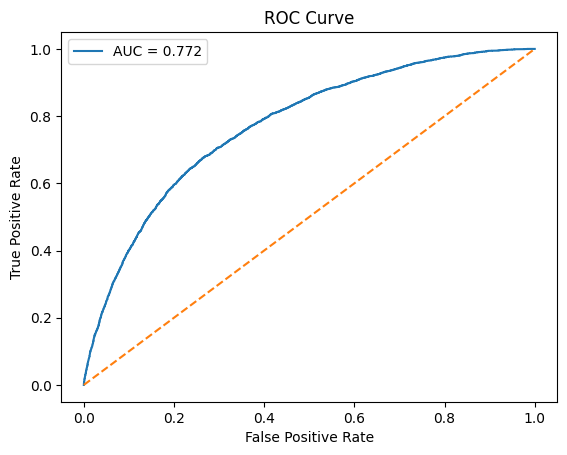

In [42]:
# Probabilités pour la classe 1 (churn)
y_proba = xgb.predict_proba(X_test)[:, 1]

# Calcul ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # ligne aléatoire
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [43]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

hgb.fit(X_train, y_train)


,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",6
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_dtyp

In [44]:
y_pred= hgb.predict(X_test)

#Score on test data
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94     39669
           1       0.01      0.60      0.03       104

    accuracy                           0.89     39773
   macro avg       0.51      0.74      0.49     39773
weighted avg       1.00      0.89      0.94     39773



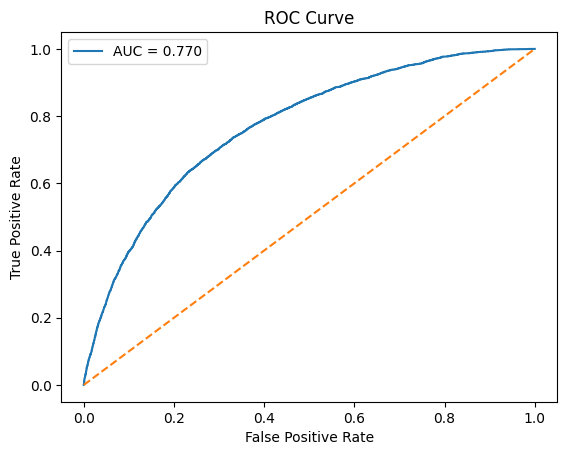

In [45]:
# Probabilités pour la classe 1 (churn)
y_proba = hgb.predict_proba(X_test)[:, 1]

# Calcul ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # ligne aléatoire
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [12]:
!pip install catboost

AUC : 0.7975332253425517
F1  : 0.3628412717172911


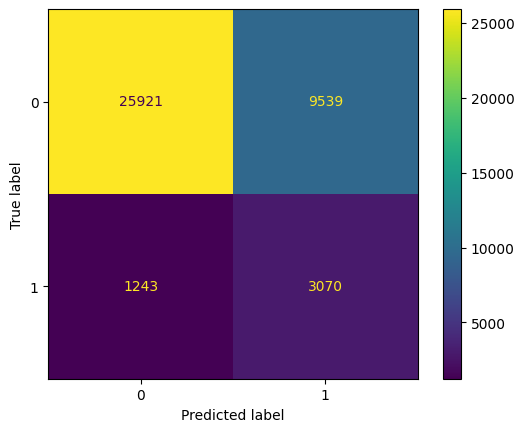

In [13]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Copie propre des données
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

# Identifier les colonnes catégorielles
cat_features = X_train_cb.select_dtypes(include=["object"]).columns.tolist()

# Remplacer NaN catégorielles par "Missing" + conversion en string
for col in cat_features:
    X_train_cb[col] = X_train_cb[col].fillna("Missing").astype(str)
    X_test_cb[col]  = X_test_cb[col].fillna("Missing").astype(str)

# Remplacer NaN numériques par médiane
num_cols = X_train_cb.select_dtypes(exclude=["object"]).columns
for col in num_cols:
    median_value = X_train_cb[col].median()
    X_train_cb[col] = X_train_cb[col].fillna(median_value)
    X_test_cb[col]  = X_test_cb[col].fillna(median_value)

# Calcul du poids pour classe déséquilibrée
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Modèle CatBoost
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=0
)

# Entraînement
model.fit(X_train_cb, y_train, cat_features=cat_features)

# Prédictions
y_pred = model.predict(X_test_cb)
y_proba = model.predict_proba(X_test_cb)[:, 1]

# Évaluation
print("AUC :", roc_auc_score(y_test, y_proba))
print("F1  :", f1_score(y_test, y_pred))

# Matrice de confusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()


In [14]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.73      0.95      0.83     27164
           1       0.71      0.24      0.36     12609

    accuracy                           0.73     39773
   macro avg       0.72      0.60      0.60     39773
weighted avg       0.72      0.73      0.68     39773

